# Worksheet 3 -- Low Rank Approximations 

## Imports

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

### Task 1 - Exploration and preprocessing

In [2]:
CLASS_NAMES = [
'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge']
with h5py.File('Galaxy10_DECals_64x64.h5') as F:
    images = np.array(F['images'])
     # shape (17736, 64, 64, 3)
    labels = np.array(F['ans'])
     # integer class labels 0..9

In [3]:
#print(images)
#print(len(labels))
#plt.imshow(images[27] / 255.)

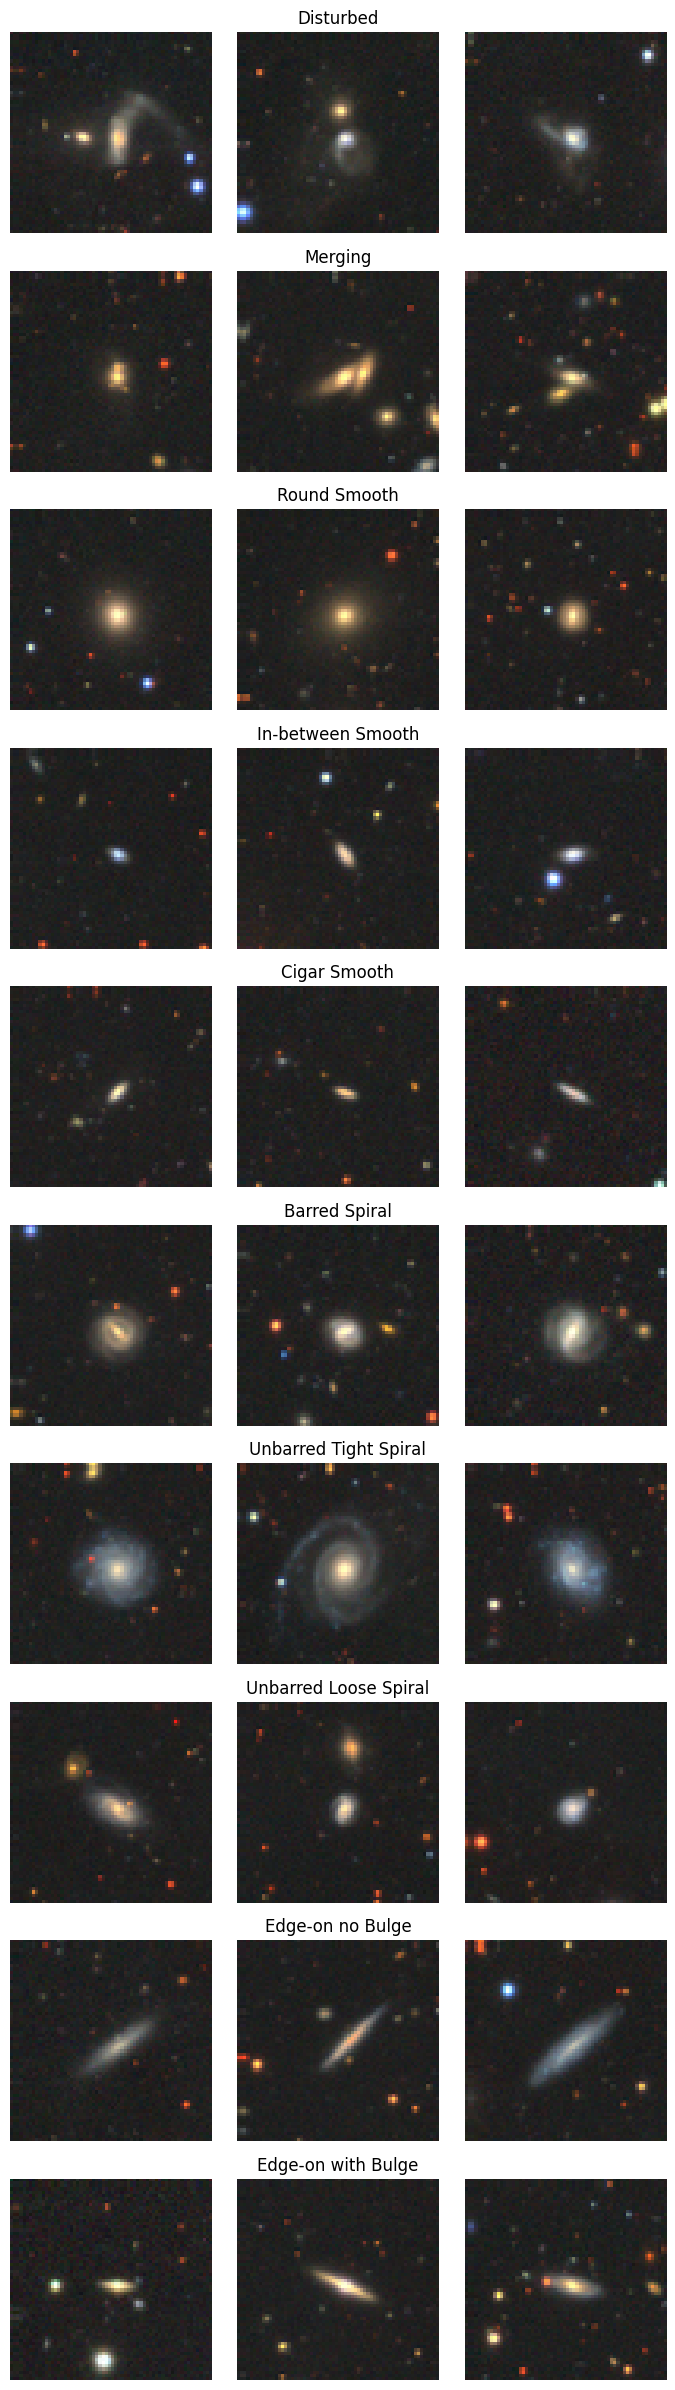

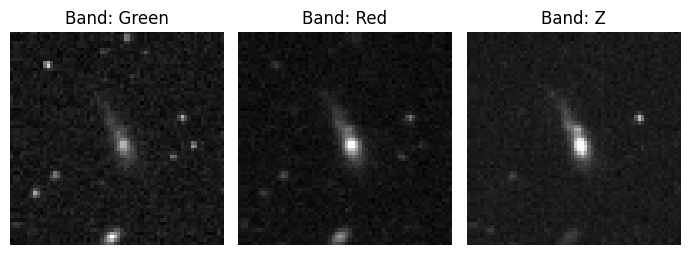

In [4]:
# For the next tasks
images_gray = images.mean(axis=-1)

fig, axes = plt.subplots(10, 3, figsize=(7, 24))
# For each class, find the first 5 examples and plot them
for class_id in range(10):
    # np.where returns indices where condition is true; [0] gets the array, [:5] takes the first 5
    idx = np.where(labels == class_id)[0][:3]
    
    # First 5 columns: RGB images
    for col, i in enumerate(idx):
        axes[class_id, col].imshow(images[i] / 255.)  # Normalize to [0,1] for display
        axes[class_id, col].axis('off')
        if col == 0:
            axes[class_id, col].set_ylabel(CLASS_NAMES[class_id], fontsize=8)

for idx, i in enumerate(CLASS_NAMES):
    axes[idx, 1].set_title(i)

plt.tight_layout()
plt.show()

# Plot of singular bands
bands = ['Green', 'Red', 'Z']
fix, axes = plt.subplots(1, 3, figsize=(7, 4))
for i in range(3):
    axes[i].imshow(images[27][:,:,i] / 255., cmap='gray')  # Show each color channel as grayscale
    axes[i].set_title(f'Band: {bands[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


### Task 2 - SVD of a single image

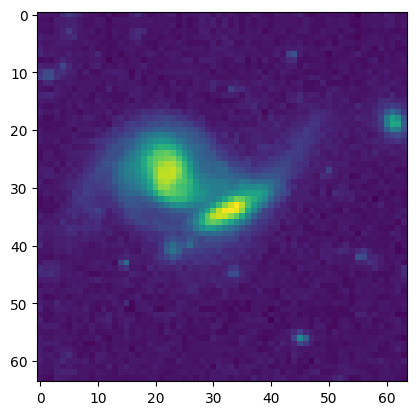

In [5]:
chosen_index = 2500
chosen_image = images_gray[chosen_index]
plt.imshow(chosen_image)

In [6]:
# From the lecture
U, S, V = np.linalg.svd(chosen_image, full_matrices=True)

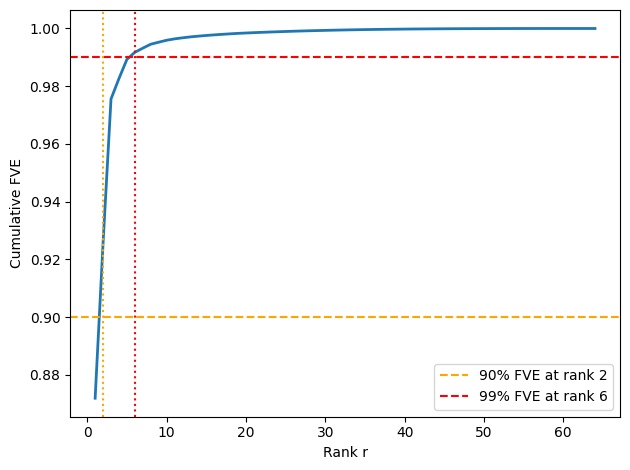

Rank needed for 90% FVE: 2
Rank needed for 99% FVE: 6


In [ ]:
def reconstruct(U, S, V, r):
    # Using matrix multiplication with @
    # Taking the first r columns of U and rows of V
    return U[:, :r] @ np.diag(S[:r]) @ V[:r, :]


r_quarter = max(1, len(S) // 4)   
r_sixteenth = max(1, len(S) // 16)

img_r_quarter = reconstruct(U, S, V, r_quarter)
img_r_sixteenth = reconstruct(U, S, V, r_sixteenth)

def fve(s):
    s_sq = s**2
    # We compute the fraction for all possible ranks first, then we'll check for specific ranks afterwards.
    return np.cumsum(s_sq) / np.sum(s_sq)

# Find the ranks at which FVE first reaches 90% and 99%
r90 = np.searchsorted(fve(S), 0.90) + 1  # +1 because searchsorted is 0-indexed
r99 = np.searchsorted(fve(S), 0.99) + 1

plt.plot(np.arange(1, len(S)+1), fve(S), lw=2)
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% FVE at rank {r90}')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% FVE at rank {r99}')
plt.axvline(r90, color='orange', linestyle=':')
plt.axvline(r99, color='red',    linestyle=':')
plt.xlabel('Rank r')
plt.ylabel('Cumulative FVE')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rank needed for 90% FVE: {r90}")
print(f"Rank needed for 99% FVE: {r99}")

In [ ]:
# We have a 64x64 image, so beta=1.

omega = 2.858
tau = omega * np.median(S)

r_hard = np.sum(S > tau)
img_hard = reconstruct(U, S, V, r_hard)

11


In [21]:
print(f"Hard threshold tau = {tau:.2f}")
print(f"Hard threshold rank = {r_hard}")

Hard threshold tau = 75.39
Hard threshold rank = 11


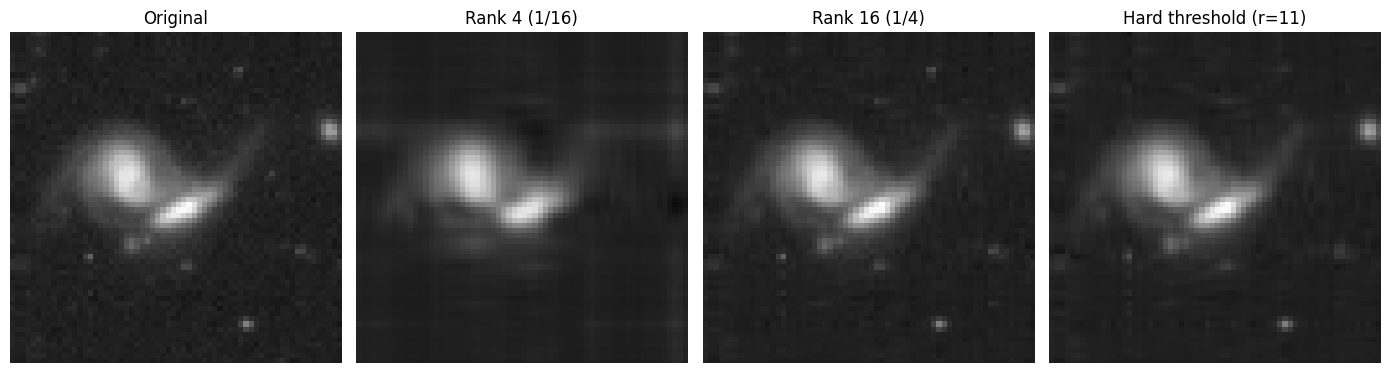

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', f'Rank {r_sixteenth} (1/16)', f'Rank {r_quarter} (1/4)', 
          f'Hard threshold (r={r_hard})']
imgs = [chosen_image, img_r_sixteenth, img_r_quarter, img_hard]

for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('task2_reconstructions.png', dpi=150)
plt.show()